In [3]:
import os, datetime
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Basic config
SEED           = 42
IMG_SIZE       = 224
BATCH_SIZE     = 16
EPOCHS         = 15
VAL_TEST_SPLIT = 0.30
DATA_DIR = "/content/plantvillage_all"
MODEL_DIR      = "models"
RUN_NAME       = f"resnet50_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

In [4]:
os.makedirs(MODEL_DIR, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)

# Optional: mixed precision on GPU (you used this before)
if tf.config.list_physical_devices("GPU"):
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("[Info] Mixed precision enabled.")
    except Exception as e:
        print("[Warn] Mixed precision not set:", e)

# Datasets (train / val / test)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=VAL_TEST_SPLIT,
    subset="training",
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=VAL_TEST_SPLIT,
    subset="validation",
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Split the validation subset into val + test
val_test_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
val_batches = val_test_batches // 2

val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# Data augmentation
data_augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.09),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augment",
)

# Build ResNet50 model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

def build_resnet50_model(num_classes: int) -> keras.Model:
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    # Augment only in training
    x = data_augment(inputs)

    # ResNet50 expects specific preprocessing (mean subtraction, etc.)
    x = preprocess_input(x)

    # Instantiate ResNet50 without input_tensor, and give it a name.
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        name="resnet50" # Explicitly name the ResNet50 instance
    )

    # Freeze base model for initial training
    base_model.trainable = True

    x = base_model(x) # Call the base_model instance on the preprocessed input tensor
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.3, name="top_dropout")(x)

    # Important: cast back to float32 when using mixed precision
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="plantvillage_resnet50")
    return model

model = build_resnet50_model(num_classes)
model.summary()

# Compile (frozen base)
initial_lr = 1e-4
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_lr),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
checkpoint_path = os.path.join(MODEL_DIR, f"{RUN_NAME}.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-7,
    ),
]

# Unfreeze last few blocks of ResNet50
fine_tune_at = 10

base_model = model.get_layer("resnet50")
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


[Info] Mixed precision enabled.
Found 54318 files belonging to 38 classes.
Using 38023 files for training.
Found 54318 files belonging to 38 classes.
Using 16295 files for validation.
Classes: 38 ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', '

Model: "plantvillage_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augment        │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augment[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augment[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augment[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_dropout         │ (None, 2048)      │          0 │ global_avg_pool[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 38)        │     77,862 │ top_dropout[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,665,574 (90.28 MB)

 Trainable params: 23,612,454 (90.07 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [5]:
history_stage2 = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
)

# Final evaluation
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/15
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6236 - loss: 1.5365
Epoch 1: val_accuracy improved from -inf to 0.96537, saving model to models/resnet50_20251230_064523.keras
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 525s 199ms/step - accuracy: 0.6237 - loss: 1.5362 - val_accuracy: 0.9654 - val_loss: 0.1187 - learning_rate: 1.0000e-05
Epoch 2/15
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9603 - loss: 0.1401
Epoch 2: val_accuracy improved from 0.96537 to 0.97790, saving model to models/resnet50_20251230_064523.keras
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 474s 198ms/step - accuracy: 0.9603 - loss: 0.1401 - val_accuracy: 0.9779 - val_loss: 0.0714 - learning_rate: 1.0000e-05
Epoch 3/15
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9786 - loss: 0.0713
Epoch 3: val_accuracy did not improve from 0.97790
2377/2377 ━━━━━━━━━━━━━━━━━━━━ 470s 196ms/step - accuracy: 0.9786 - loss: 0.0713 - val_accuracy: 0.9774 - val_loss: 0.0890 - learning_rate: 1.0000e-05
Epoch 4/1

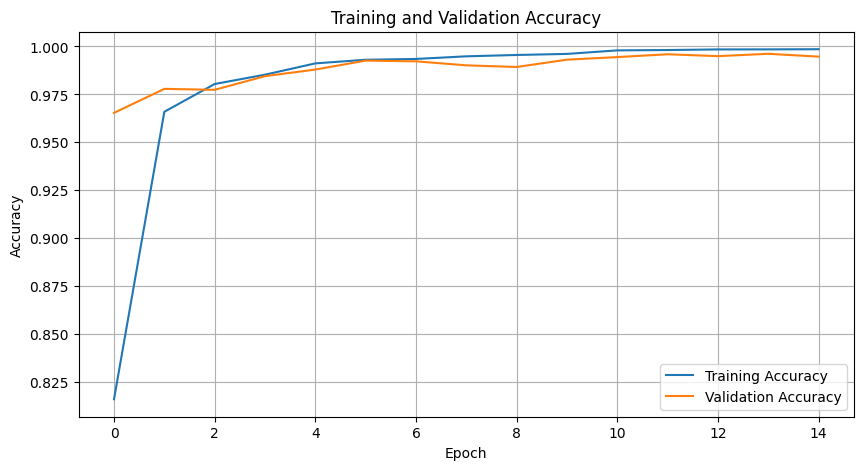

In [10]:
import matplotlib.pyplot as plt

# Extract history from the tuple
history = history_stage2

# Plotting accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

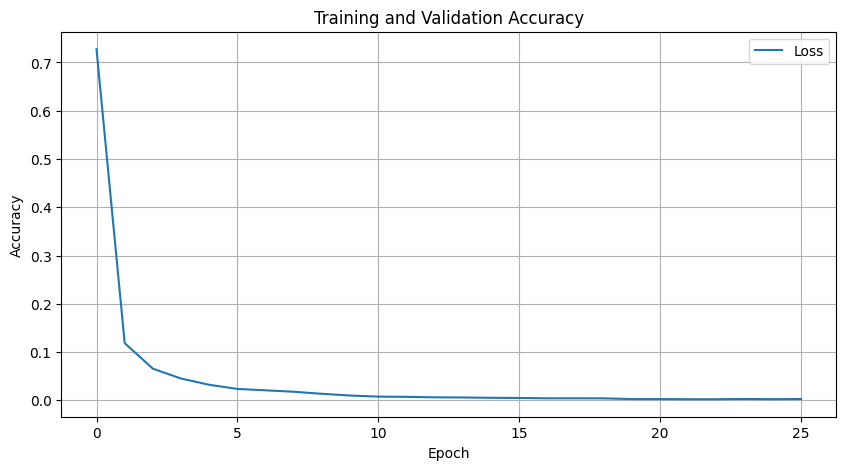

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get predictions on test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print metrics
print("MODEL PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Optional: Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


MODEL PERFORMANCE METRICS
Accuracy:  0.9974
Precision: 0.9974
Recall:    0.9974
F1-Score:  0.9974

Detailed Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      1.00      0.99        92
                                 Apple___Black_rot       1.00      1.00      1.00        99
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        40
                                   Apple___healthy       1.00      1.00      1.00       253
                               Blueberry___healthy       1.00      1.00      1.00       216
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       181
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       132
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.98      0.97        86
                       Corn_(maize)___Co

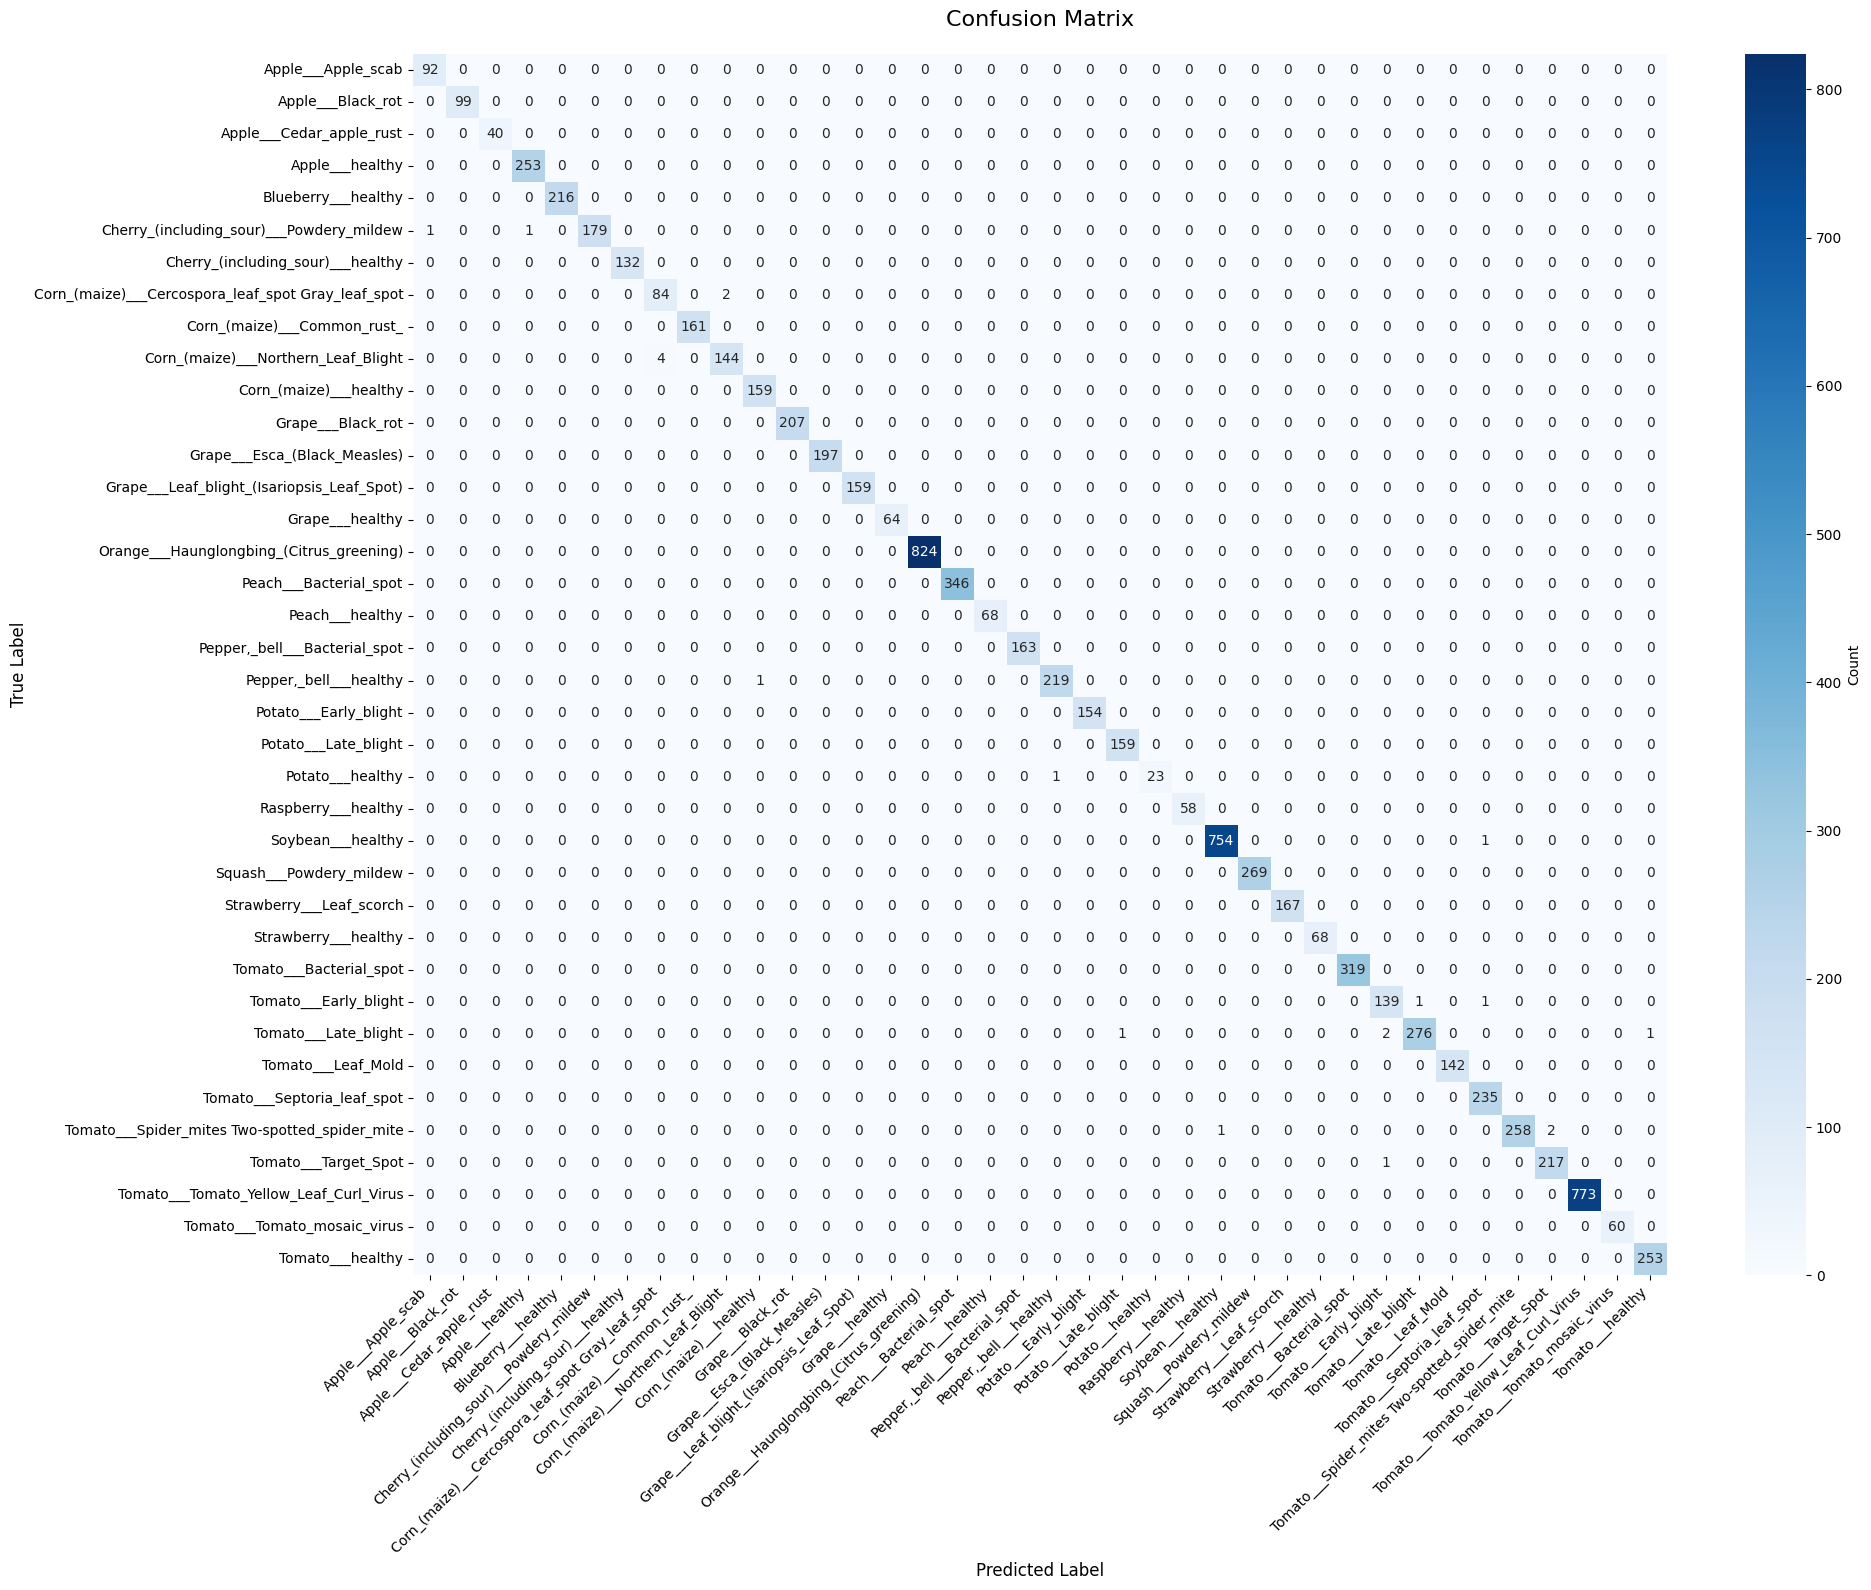


Confusion Matrix Shape: (38, 38)
Total Predictions: 8151
Correct Predictions: 8130
Misclassifications: 21


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create figure
plt.figure(figsize=(20, 16))

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print confusion matrix statistics
print("\nConfusion Matrix Shape:", cm.shape)
print(f"Total Predictions: {cm.sum()}")
print(f"Correct Predictions: {np.trace(cm)}")
print(f"Misclassifications: {cm.sum() - np.trace(cm)}")
